# Accessing Euclid Q1 data in the cloud

**AAS workshop:** *Euclid Data in the Cloud - Access, Analysis, and Science Opportunities* (90 min)

_Notebook 2 of 4._ Goal: get comfortable pulling each Euclid Q1 data product out of [IRSA](https://irsa.ipac.caltech.edu/) **without downloading the whole release**. All Q1 data products live in a public AWS S3 bucket — `nasa-irsa-euclid-q1` — and IRSA exposes three thin services on top of them:

| If you want... | use this | example |
| --- | --- | --- |
| catalog rows (photometry, redshifts, line measurements) | **TAP** (`Irsa.query_tap`) | MER catalog, SPE line features, PHZ |
| an image cutout at a position | **SIA** (`Irsa.query_sia`) | MER mosaics (VIS, Y, J, H) |
| the full FITS file (or a custom slice of it) | **direct S3** (`fits.open('s3://...')`) | SIR 1D spectra, full mosaics |

We'll use one EDF-N target and pull each of its data products in turn. Same patterns scale unchanged to millions of sources and to DR1 later.

Adapted from the [IRSA Euclid Q1 cloud-access tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-cloud-access/).

## Quick orientation — what *is* TAP, SIA, and "cloud"?

A short glossary before the code starts. The terms below recur throughout the workshop, and the distinctions between them matter when something doesn't work the way you expect.

**Two layers.** Any IRSA cloud-hosted dataset (Euclid Q1, WISE, Spitzer SEIP, ZTF, ...) is built from two separate pieces:

1. **The bytes** — the FITS files (mosaics, spectra) and the rows of catalog tables. The FITS files live in mission-specific public S3 buckets — for our case, `nasa-irsa-euclid-q1`. The catalog rows live in a relational database at IPAC.
2. **The services that answer queries** — web servers at `irsa.ipac.caltech.edu` that you talk to over HTTP. Each speaks a particular *protocol*. You send a query, they send back a result (rows, or pointers to files).

You always go through a service to find data — you do not browse the S3 bucket by hand.

**TAP** (*Table Access Protocol*) answers questions about **rows in tables**. You send it ADQL — Astronomical Data Query Language, essentially SQL with cone-search extensions — and get back rows. The MER catalog, the SPE line catalog, the photo-z catalog, and the spectrum-association table all live behind TAP. Same endpoint, different tables.

**SIA** (*Simple Image Access*) answers one specific question about **images**: *which image files cover this position on the sky?* It returns a table where each row is one image, with metadata (band, exposure, S3 URI). SIA gives you *pointers*, not pixels — you fetch the pixels yourself afterward.

Both protocols are IVOA (International Virtual Observatory Alliance) standards. They are not IRSA-specific: archives like ESAC, CADC, and MAST implement the same protocols, so the patterns below transfer.

**`astroquery.ipac.irsa.Irsa`** is the Python wrapper. It knows IRSA's TAP and SIA endpoint URLs and parses the responses for you. `Irsa.query_tap(...)`, `Irsa.query_sia(...)`, and `Irsa.query_region(...)` are thin wrappers over the same two endpoints. The same work can be done with `requests.get(...)`; astroquery removes the boilerplate.

**What "cloud" means here.** The FITS files have moved from disks at IPAC to AWS S3 (`s3://nasa-irsa-euclid-q1/...` for Q1; analogous buckets for other missions). The query services that tell you where each file lives still run at IPAC. Access is anonymous and public — no AWS credentials required; `fsspec_kwargs={'anon': True}` is what tells `s3fs` to skip credential lookup. The same code works from a laptop or from a notebook running inside AWS, but in the same AWS region (e.g. NASA Fornax in `us-east-1`) the bytes never traverse the public internet and transfers are substantially faster.

**The path you will see four times below:**

```
your code  →  IRSA service (TAP / SIA)  →  back: rows or S3 pointer
                                            ↓ if pointer:
                                          fits.open('s3://...')  →  bytes
```

## 0. Setup

Three libraries do almost all the work:

- **`astroquery.ipac.irsa.Irsa`** — talks to IRSA's TAP and SIA endpoints.
- **`astropy.io.fits`** + **`fsspec`/`s3fs`** — opens FITS files from S3 URIs without downloading them.
- **`astropy`** — units, coordinates, table handling.

If `astroquery` is < 0.4.10, upgrade it (`pip install -U astroquery`) — earlier versions don't know how to talk to IRSA's cloud-aware SIA service.

In [21]:
import json

import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from astropy.wcs import WCS
from astroquery.ipac.irsa import Irsa

# Retry wrappers around Irsa.* — IRSA's TAP/SIA endpoints occasionally return
# 502/503/504 under load; these wrappers retry with exponential backoff so the
# notebook keeps moving when the server hiccups. Use tap_query_with_retry for
# ADQL TAP calls, and irsa_with_retry(fn, ...) for any other Irsa.* call.
from workshop_utils import tap_query_with_retry, irsa_with_retry

# Our example target: a single source in the Euclid Deep Field North (EDF-N).
# We'll use these RA/Dec to demo every access pattern below — first finding the
# MER source at this position, then its mosaic cutouts, spectrum, and lines.
TARGET = SkyCoord(ra=268.480587 * u.deg, dec=64.780647 * u.deg)
print(f'Target: RA, Dec = {TARGET.ra.deg:.6f}, {TARGET.dec.deg:.6f}')

Target: RA, Dec = 268.480587, 64.780647


## 1. MER catalog — TAP cone search

The MER (Mosaic + Extraction) catalog is the workhorse photometric catalog — one row per detected source, with positions, fluxes in every band, and stellar/galaxy classifications. The table name in IRSA is **`euclid_q1_mer_catalogue`** and its source identifier column is **`object_id`**.

Two common ways to query it:

- **`Irsa.query_region`** — a cone search around a position. Easy when you don't yet know your object_id.
- **`Irsa.query_tap`** — full ADQL. Use this when you want specific columns or when you already have a list of IDs.

We'll do the cone search first to discover what's at our position.

In [22]:
# Cone search: every MER source within 1 arcsec of TARGET. (Euclid astrometry is
# sub-arcsec, so 1\" is plenty for picking out a single source at a known position;
# widen to several arcsec if you're exploring a region rather than a known target.)
# Underlying call: Irsa.query_region(...); the irsa_with_retry wrapper retries on transient 5xx.
mer = irsa_with_retry(
    Irsa.query_region,
    coordinates=TARGET,
    spatial='Cone',
    catalog='euclid_q1_mer_catalogue',
    radius=1 * u.arcsec,
)
print(f'{len(mer)} MER source(s) within 1\".')
mer[['object_id', 'ra', 'dec', 'flux_vis_psf', 'flux_h_templfit']].pprint(max_width=120)

# Pick the first one and remember its object_id for the rest of the notebook.
object_id = int(mer['object_id'][0])
print(f'\nWe will follow object_id = {object_id}')

1 MER source(s) within 1".
     object_id           ra          dec     flux_vis_psf flux_h_templfit
                        deg          deg         uJy            uJy      
------------------- ------------ ----------- ------------ ---------------
2684805874647806467 268.48058743 64.78064676  15.63518047     29.47985077

We will follow object_id = 2684805874647806467


Same query, written in ADQL — useful when you want only specific columns or you have a list of object IDs already:

In [23]:
adql = (
    'SELECT object_id, ra, dec, flux_vis_psf, flux_h_templfit '
    'FROM euclid_q1_mer_catalogue '
    f'WHERE object_id = {object_id}'
)
# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
row = tap_query_with_retry(adql)
row.pprint(max_width=120)

     object_id           ra          dec     flux_vis_psf flux_h_templfit
                        deg          deg         uJy            uJy      
------------------- ------------ ----------- ------------ ---------------
2684805874647806467 268.48058743 64.78064676  15.63518047     29.47985077


## 2. MER mosaic — SIA spatial image search + direct S3 cutout

MER mosaics are the big background-subtracted images (~1.4 GB each, four bands per tile). You almost never want the whole mosaic — just a cutout around your source. Two steps:

1. **SIA query** (`Irsa.query_sia`) — "which mosaics cover this position?" Returns one row per (tile × band).
2. **Direct S3 open** — open the chosen FITS straight from the bucket with `fsspec`, then use `Cutout2D` to grab just the region you want. The unread bytes never move across the network.

The MER mosaic SIA collection is **`euclid_DpdMerBksMosaic`**.

In [24]:
# Step 1: find all mosaics covering TARGET. One row per tile x band.
# Underlying call: Irsa.query_sia(...); the wrapper retries on transient 5xx.
sia = irsa_with_retry(Irsa.query_sia, pos=(TARGET, 1 * u.arcsec),
                      collection='euclid_DpdMerBksMosaic')
print(f'{len(sia)} mosaic rows cover this position. Bands available:',
      sorted(set(str(b) for b in sia['energy_bandpassname'])))

# Keep the VIS row. Each row carries a `cloud_access` column with JSON describing
# where the file lives in AWS — we parse it and build the s3:// URI ourselves.
vis_row = sia[sia['energy_bandpassname'] == 'VIS'][0]
aws = json.loads(vis_row['cloud_access'])['aws']
s3_uri = f"s3://{aws['bucket_name']}/{aws['key']}"
print(f'\nVIS mosaic S3 URI:\n  {s3_uri}')

49 mosaic rows cover this position. Bands available: ['G', 'H', 'I', 'J', 'R', 'U', 'VIS', 'Y', 'Z']

VIS mosaic S3 URI:
  s3://nasa-irsa-euclid-q1/q1/MER/102158584/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158584-609CB6_20241025T015301.545851Z_00.00.fits


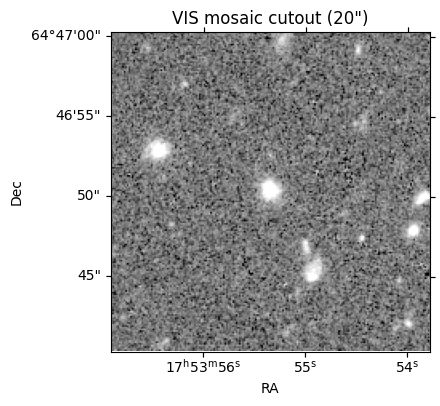

In [25]:
# Step 2: open the mosaic directly from S3 and grab a 20-arcsec cutout.
# fsspec_kwargs={'anon': True} tells s3fs to use anonymous (public) access.
with fits.open(s3_uri, fsspec_kwargs={'anon': True}) as hdul:
    wcs = WCS(hdul[0].header)
    cutout = Cutout2D(hdul[0].section, position=TARGET, size=20 * u.arcsec, wcs=wcs)

norm = ImageNormalize(cutout.data, interval=PercentileInterval(99), stretch=AsinhStretch())
fig, ax = plt.subplots(figsize=(4.5, 4.5), subplot_kw={'projection': cutout.wcs})
ax.imshow(cutout.data, origin='lower', cmap='gray', norm=norm)
ax.set_title('VIS mosaic cutout (20")')
ax.set_xlabel('RA'); ax.set_ylabel('Dec')
plt.tight_layout(); plt.show()

**Note on `.section` vs `.data`.** `hdul[0].section` reads only the pixels `Cutout2D` actually asks for — `hdul[0].data` would force the whole array into memory. For ~1.4 GB Q1 mosaics this matters a lot from a laptop.

**Shortcut: server-side cutouts via IRSA Image Server.** IRSA's [Image Server](https://irsa.ipac.caltech.edu/ibe/) (the `/ibe/` endpoint, which also fronts the SIA/SSA/TAP services used elsewhere in this notebook) exposes a URL-based cutout endpoint. Append `?center=ra,dec&size=Xarcsec` to a mosaic URL and the server returns the cropped FITS directly, no client-side `Cutout2D` needed. The tradeoff: you get a small FITS without WCS bookkeeping work, but you lose the option to do anything cleverer than a square crop. We use this path via `workshop_utils.get_Q1_mer_cutout` in notebook 4.

## 3. SIR 1D spectrum — TAP association + direct S3

SIR (Spectroscopy from Infrared) 1D spectra live in big multi-extension FITS files, hundreds of spectra per file. To find the right one for your object you need **two** cloud calls:

1. TAP query against the **spectrum-association table** `euclid.objectid_spectrafile_association_q1` — returns a `path` for your object that encodes both the FITS file location and the HDU index inside it.
2. Open that FITS straight from S3 and read the named HDU as an astropy Table.

Watch the ID column name: in this table it's **`objectid`** (one word). Other Euclid tables use `object_id`. 

In [26]:
# Step 1: which FITS holds the spectrum?
# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
assoc = tap_query_with_retry(
    'SELECT objectid, path '
    'FROM euclid.objectid_spectrafile_association_q1 '
    f'WHERE objectid = {object_id}'
)
print(f'Association returned {len(assoc)} row(s).')
print(f'  path: {assoc["path"][0]}')

# Step 2: the `path` column packs everything we need. It looks like:
#   api/spectrumdm/convert/euclid/q1/SIR/.../EUC_SIR_W-COMBSPEC_*.fits?...&hdu=NNNN
# The bit before '?' is the S3 key (after stripping the API prefix).
# The HDU index is encoded in the query string. Parsing both with urllib.parse:
from urllib.parse import urlparse, parse_qs
parsed = urlparse(str(assoc['path'][0]))
key = parsed.path.replace('api/spectrumdm/convert/euclid/', '')
hdu_idx = int(parse_qs(parsed.query)['hdu'][0])
s3_uri = f's3://nasa-irsa-euclid-q1/{key}'
print(f'\nReading HDU {hdu_idx} from\n  {s3_uri}')

Association returned 1 row(s).
  path: api/spectrumdm/convert/euclid/q1/SIR/102158584/EUC_SIR_W-COMBSPEC_102158584_2024-11-05T15:26:12.411170Z.fits?dataset_id=euclid_combspec&hdu=6438

Reading HDU 6438 from
  s3://nasa-irsa-euclid-q1/q1/SIR/102158584/EUC_SIR_W-COMBSPEC_102158584_2024-11-05T15:26:12.411170Z.fits


531 wavelength samples; columns: ['WAVELENGTH', 'SIGNAL', 'MASK', 'QUALITY', 'VAR', 'NDITH']
  → 503 good samples plotted (QUALITY > 0.5)
  spec-z = 1.631  (probability = 0.99)


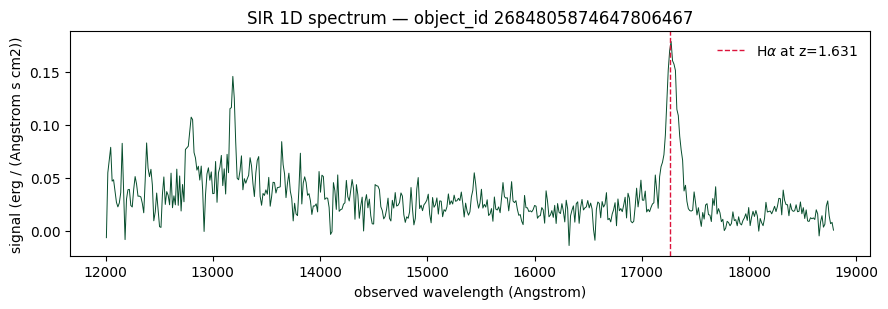

In [27]:
# Open the FITS straight from S3 and pull out just the one HDU we want.
with fits.open(s3_uri, fsspec_kwargs={'anon': True}) as hdul:
    spec = Table.read(hdul[hdu_idx])

print(f'{len(spec)} wavelength samples; columns: {spec.colnames}')

# Each SIR row carries QUALITY (continuous in [0, 1], higher = better; the
# pipeline penalises bad pixels, low throughput, edge effects, etc.) and a
# bitmask MASK with per-pixel flags. For a clean plot, keep QUALITY > 0.5 —
# that drops the few obviously bad pixels without throwing away the moderate
# warnings that bit MASK==0 would discard. Also trim to the well-calibrated
# core of the NISP red-grism range.
good = ((spec['QUALITY'] > 0.5)
        & (spec['WAVELENGTH'] > 12000)
        & (spec['WAVELENGTH'] < 18800))
print(f'  → {good.sum()} good samples plotted (QUALITY > 0.5)')

# Grab a redshift so we can mark observed Halpha on the plot. Euclid exposes
# several redshift catalogs on TAP, split by source type:
#   - euclid_q1_spectro_zcatalog_spe_qso_candidates    (QSOs — best for ours)
#   - euclid_q1_spectro_zcatalog_spe_galaxy_candidates (galaxies)
#   - euclid_q1_phz_photo_z                            (photo-z; for this AGN
#                                                       it gives 0.87, wildly
#                                                       off — broad-line QSOs
#                                                       break photo-z templates)
# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
z_row = tap_query_with_retry(
    'SELECT spe_z, spe_z_prob '
    'FROM euclid_q1_spectro_zcatalog_spe_qso_candidates '
    f'WHERE object_id = {object_id} AND spe_rank = 0'
)
z = float(z_row['spe_z'][0])
print(f'  spec-z = {z:.3f}  (probability = {float(z_row["spe_z_prob"][0]):.2f})')
halpha_obs = 6562.8 * (1 + z)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(spec['WAVELENGTH'][good], spec['SIGNAL'][good], lw=0.7, color='#064d2c')
ax.axvline(halpha_obs, ls='--', color='crimson', lw=1.0,
           label=f'H$\\alpha$ at z={z:.3f}')
ax.set_xlabel(f'observed wavelength ({spec["WAVELENGTH"].unit})')
ax.set_ylabel(f'signal ({spec["SIGNAL"].unit})')
ax.set_title(f'SIR 1D spectrum — object_id {object_id}')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout(); plt.show()

## 4. SPE line catalog — one more TAP query

Euclid's SPE pipeline measures emission/absorption lines on every SIR spectrum and stores Gaussian-fit parameters (flux, EW, S/N) per line in **`euclid_q1_spe_lines_line_features`**. ID column is `object_id` (with underscore — note the inconsistency vs §3). Filter on `spe_line_name` to grab a specific line.

In [28]:
# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
lines = tap_query_with_retry(
    'SELECT spe_line_name, spe_line_central_wl_gf, '
    'spe_line_flux_gf, spe_line_snr_gf, spe_line_ew_gf '
    'FROM euclid_q1_spe_lines_line_features '
    f'WHERE object_id = {object_id} AND spe_line_snr_gf > 3'
)
print(f'{len(lines)} S/N > 3 line(s) for this source:')
lines.pprint(max_width=120)

9 S/N > 3 line(s) for this source:
spe_line_name spe_line_central_wl_gf spe_line_flux_gf spe_line_snr_gf spe_line_ew_gf
------------- ---------------------- ---------------- --------------- --------------
        Hbeta            12801.71191  5.605129885e-16     10.18372536   -148.7173462
     OIII5008            13174.05566  6.580810196e-16      17.5894146   -143.8699493
       Halpha            17265.53906  1.281320609e-15     40.71139908   -498.4153442
      NII6585            17319.87695  7.084633334e-16     40.71139908    -367.442749
      SII6718            17660.69922  1.147097678e-16     4.408014297   -97.46406555
      OII3727            17275.47266  2.038733342e-15     47.28120422   -836.8654785
     OIII5008            17282.41602  2.930701387e-15     65.84490967   -3634.238281
      NeV3426            17275.46094  1.979634371e-15     45.98228836   -751.1957397
       PaBeta            17275.46875  2.025714869e-15     46.92055893   -816.8875732


## How do I know what tables and columns exist?

The four examples above each hard-coded a table name (`euclid_q1_mer_catalogue`,
`euclid.objectid_spectrafile_association_q1`, ...) and column names
(`object_id` vs `objectid`, `flux_h_templfit`, `spe_line_name`, ...). Where do
those names come from?

The authoritative source is **TAP_SCHEMA**, a set of meta-tables every TAP
server exposes that describe every other table. Two queries get you everything:

- `SELECT * FROM TAP_SCHEMA.tables WHERE ...` — every table on the server.
- `SELECT * FROM TAP_SCHEMA.columns WHERE table_name = '...'` — every column in a table.

`astroquery` also has convenience helpers — `Irsa.list_catalogs()`,
`Irsa.list_columns(catalog=...)`, `Irsa.list_collections()` — but be aware that
`list_catalogs` only surfaces IRSA's *curated* catalog list, not every TAP table
(e.g. SPE line catalogs and the spectrum-association table are missing from it).
For complete discovery, query `TAP_SCHEMA` directly as below.

If you'd rather click than type:

- [IRSA Holdings for Euclid](https://irsa.ipac.caltech.edu/Missions/euclid.html) — human-readable list of catalogs and image products.
- [IRSA TAP schema browser](https://irsa.ipac.caltech.edu/TAP/sync?REQUEST=doTablesGet) — every table on the server, with column lists.

In [29]:
# `list_catalogs` shows only IRSA's curated "catalogs" — typically the cone-
# searchable ones. The SPE line catalog, the spectrum-association table, etc.
# are on TAP but not registered as "catalogs". For the full picture, query
# TAP_SCHEMA.tables directly:
# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
schema = tap_query_with_retry(
    "SELECT schema_name, table_name, description "
    "FROM TAP_SCHEMA.tables "
    "WHERE LOWER(table_name) LIKE '%euclid%' "
    "   OR LOWER(schema_name) = 'euclid'"
)
print(f'{len(schema)} Euclid tables on IRSA TAP:')
schema.pprint(max_lines=-1, max_width=140)

# Columns of any table: query TAP_SCHEMA.columns. (Or use Irsa.list_columns
# for the catalogs that list_catalogs knows about.)
print('\nFirst 10 columns of euclid_q1_mer_catalogue:')
# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
cols = tap_query_with_retry(
    "SELECT column_name, description, unit "
    "FROM TAP_SCHEMA.columns "
    "WHERE table_name = 'euclid_q1_mer_catalogue'"
)
cols[:10].pprint(max_width=140)
print(f'  ... ({len(cols)} columns total)')

# Every SIA image collection (mosaics, calibration frames, ...).
# Underlying call: Irsa.list_collections(...); the wrapper retries on transient 5xx.
print('\nEuclid SIA collections:')
irsa_with_retry(Irsa.list_collections, filter='euclid').pprint(max_lines=-1, max_width=120)

26 Euclid tables on IRSA TAP:
schema_name                     table_name                                         description                      
----------- ------------------------------------------------- ------------------------------------------------------
     euclid            euclid_q1_spe_lines_continuum_features       Euclid Q1 SPE Lines Catalog - Continuum Features
     euclid                euclid_q1_spe_lines_atomic_indices           Euclid Q1 SPE Lines Catalog - Atomic Indices
     euclid             euclid_q1_spe_lines_molecular_indices        Euclid Q1 SPE Lines Catalog - Molecular Indices
     euclid euclid_q1_spectro_model_catalog_spe_lines_catalog                   Euclid Q1 SPE Models Catalog - Lines
     euclid   euclid_q1_spectro_model_catalog_spe_star_models                      Euclid Q1 SPE Star Models Catalog
     euclid        euclid.objectid_spectrafile_association_q1 Euclid Q1 Object ID to Spectral File Association Table
     euclid                      e

## When TAP isn't the right tool — HATS catalogs on S3

Everything above goes through IRSA's TAP/SIA services. Those services are well suited to **targeted queries** — one object, one cone, one cross-match — but they round-trip every request through a server at IPAC, and per-query overhead adds up if you want to pull millions of rows or scan a catalog by column rather than by position.

For that workload Euclid Q1 also ships in **HATS** format (*Hierarchical Adaptive Tiling Scheme*): the merged-object catalog stored as **partitioned Apache Parquet on S3**, indexed spatially by HEALPix pixel. You read it directly with `pyarrow` — no query service in the loop — and `pyarrow`'s columnar filtering pushes selections down to the file format, so column-wise scans over tens of millions of rows are fast and cheap.

```
s3://nasa-irsa-euclid-q1/contributed/q1/merged_objects/hats/
    euclid_q1_merged_objects-hats/dataset
```

Rough rule of thumb:

| Use case | Reach for |
| --- | --- |
| One object, or sources near one position | **TAP** (this notebook) |
| Image cutout at one position | **SIA + direct S3** (this notebook) |
| "Every source with z > 5" / population statistics / column-wise selections at scale | **HATS** + `pyarrow` |
| Distributed / multi-node analyses across the full catalog | **HATS** + `lsdb` / `dask` |

Full walk-through with working code: [IRSA Euclid Q1 HATS tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-q1-hats-intro/). The same `fsspec_kwargs={'anon': True}` / `S3FileSystem(anonymous=True)` idea applies — public bucket, no credentials.